In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df_all = pd.read_pickle("../data/tags_alteration_full_2025-10_dm.pkl")

In [3]:
df = df_all[df_all['status'] != 'non-legit'].copy()
df = df[df['old_snap_timestamp'] >= pd.Timestamp('2016-02-23')]

print(f"Total alterations: {len(df_all):_}")
print(f"Alterations used (excluding non-legit): {len(df):_}")
print(f"Non-legit filtered out: {len(df_all) - len(df):_}")

Total alterations: 15_166_153
Alterations used (excluding non-legit): 10_171_046
Non-legit filtered out: 4_995_107


In [4]:
print(f"Amount of legit alterations (after 2015-09-17): {len(df):_}") 

Amount of legit alterations (after 2015-09-17): 10_171_046


In [5]:
analyzed_origins = 328_424_115 # more than 1 snapshot
skipped_origins = 74_425_148 # 1 snapshot or less
relevant_origins = 45_525_442 # at least 1 tag and 2 snapshots
total_tags = 3_197_620_436
total_l_tags = 1_417_510_761
total_a_tags = 1_780_109_675
unknown_branch = 819

# SSC Attack

Forks of `tj-actions/changed-files`

In [6]:
df[(df['origin_url'].str.contains("changed-files")) & (df['new_revision'].str.contains('0e58ed8'))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
2198205,https://github.com/zendesk/changed-files,refs/tags/v18.7,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:a59f800cbb60ed483623848e31be67659a2940f8,2022-04-08 09:43:01,swh:1:dir:06e64979ae45fcd6a2a9b8b91b4a81cbcabe8e65,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198207,https://github.com/zendesk/changed-files,refs/tags/v37.2.0,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:68b429ddc666ea0dba46309e1ee45e06bb408df8,2023-07-18 17:41:01,swh:1:dir:ccab5fe2e97c81819606b28711e170e37904cc43,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198209,https://github.com/zendesk/changed-files,refs/tags/v18.4,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:e35d0afdc1f0b01f84ec0f4cdf1b179325634b36,2022-03-21 01:30:28,swh:1:dir:f4e749fa02bfc8a8a9ee4d5816586302a6d01619,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198211,https://github.com/zendesk/changed-files,refs/tags/v37.5.1,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:a96679dfee2a1e64b1db5a210c0ffaf1f2cb24ce,2023-07-28 19:34:23,swh:1:dir:63692aa7571c374eac46d4f60f044e7c67659fba,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198213,https://github.com/zendesk/changed-files,refs/tags/v34.0.0,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:c4d29bf5b2769a725bcc9a723c498ba9c34c05b4,2022-10-25 22:04:27,swh:1:dir:3940140177acbd1edeb44d119c2508ebae1f712f,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2198893,https://github.com/zendesk/changed-files,refs/tags/v43.0.1,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:20576b4b9ed46d41e2d45a2256e5e2316dde6834,2024-03-20 21:58:07,swh:1:dir:785398deebfb6e69eebd65156e7472f980c955de,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198895,https://github.com/zendesk/changed-files,refs/tags/v35.6.3,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024

# Proportions

In [6]:
print(f"Amount of Alterations: {len(df):_}")
print(f"Meaning {(len(df)/total_tags)*100:.2f}% of total tags")

Amount of Alterations: 10_171_046
Meaning 0.32% of total tags


In [7]:
moves = df[df['category']=="Alteration"]
deletions = df[df['category']=="Deletion"]

In [8]:
annotated = df[df['type']=="annotated"]
lightweight = df[df['type']=="lightweight"]
unique_origins = df[['origin_url', 'stars']].drop_duplicates().reset_index(drop=True)

In [9]:
print(f"Unique origins with 100 stars or more: {len(unique_origins[unique_origins['stars']>=100]):_}")
print(f"Unique origins with 1000 stars or more: {len(unique_origins[unique_origins['stars']>=1000]):_}")

Unique origins with 100 stars or more: 13_450
Unique origins with 1000 stars or more: 4_118


In [10]:
print(f"Origin with an altered tag: {(len(unique_origins)):_} -> {(len(unique_origins)/relevant_origins)*100:.2f}%")
print(f"Proportion of altered annotated tags: {(len(annotated)/total_a_tags)*100:.2f}%")
print(f"Proportion of altered lightweight tags: {(len(lightweight)/total_l_tags)*100:.2f}%")

Origin with an altered tag: 188_713 -> 0.41%
Proportion of altered annotated tags: 0.25%
Proportion of altered lightweight tags: 0.41%


In [11]:
legit_moves = df[((df['creation_root_dir'].notna()) | (df['new_root_dir'].notna()))]
print(f'Amount of moves (direct or deletion->creation): {len(legit_moves):_}')

Amount of moves (direct or deletion->creation): 626_008


In [12]:
ch_dir = legit_moves[(legit_moves['old_root_dir'] != legit_moves['new_root_dir']) & (legit_moves['old_root_dir'] != legit_moves['creation_root_dir'])]
metadata_dir = legit_moves[(legit_moves['old_root_dir']==legit_moves['new_root_dir']) | (legit_moves['old_root_dir']==legit_moves['creation_root_dir'])]
print(f"Amount of moves that changed the content of the tag: {len(ch_dir):_}")
print(f"Amount of moves that changed only the metadata: {len(metadata_dir):_}")
print(f"Proportion of moves that change the content: {(len(ch_dir)/len(legit_moves))*100:.2f}%")
print(f"Proportion of moves that change only the metadata: {(len(metadata_dir)/len(legit_moves))*100:.2f}%")


Amount of moves that changed the content of the tag: 426_595
Amount of moves that changed only the metadata: 199_413
Proportion of moves that change the content: 68.15%
Proportion of moves that change only the metadata: 31.85%


# Temporal Evolution of Tag Alterations

In [13]:
# Convert timestamps to datetime and extract year-month
df['alteration_date'] = pd.to_datetime(df['new_snap_timestamp'], unit='s', errors='coerce')
df['alteration_month'] = df['alteration_date'].dt.strftime('%Y-%m')

# Group alterations by month
alterations_by_month = df.groupby('alteration_month').agg({
    'tag_name': 'count',  # Total alterations
    'type': lambda x: (x == 'annotated').sum()  # Annotated alterations
}).rename(columns={'tag_name': 'total_alterations', 'type': 'annotated_alterations'})

# Calculate lightweight alterations
alterations_by_month['lightweight_alterations'] = (
    alterations_by_month['total_alterations'] - alterations_by_month['annotated_alterations']
)

# Reset index to make month a column
alterations_by_month = alterations_by_month.reset_index()

In [14]:
net_changes_data = []

with open('../data/counts/counts.log', 'r') as f:
    # Skip lines until we find the header
    for line in f:
        if line.strip().startswith('Month'):
            # Skip the separator line
            next(f)
            break
    
    # Parse data lines
    for line in f:
        line = line.strip()
        if not line or line.startswith('Final cumulative'):
            break
        
        # Parse lines with format: "2016-02            364530        20208       344322          344322"
        parts = line.split()
        if len(parts) >= 5:
            try:
                month = parts[0]
                added = int(parts[1])
                removed = int(parts[2])
                net_change = int(parts[3])
                cumulative = int(parts[4])
                
                net_changes_data.append({
                    'month': month,
                    'added': added,
                    'removed': removed,
                    'net_change': net_change,
                    'cumulative': cumulative
                })
            except (ValueError, IndexError):
                # Skip lines that don't match expected format
                continue

# Create DataFrame
net_changes_df = pd.DataFrame(net_changes_data)

print(f"Loaded {len(net_changes_df):_} months of data")
print(f"\nDate range: {net_changes_df['month'].iloc[0]} to {net_changes_df['month'].iloc[-1]}")
print(f"\nTotal tags added: {net_changes_df['added'].sum():_}")
print(f"Total tags removed: {net_changes_df['removed'].sum():_}")
print(f"Net change: {net_changes_df['net_change'].sum():_}")
print(f"Final cumulative: {net_changes_df['cumulative'].iloc[-1]:_}")
print(f"\nFirst few rows:")
print(net_changes_df.head())
print(f"\nLast few rows:")
print(net_changes_df.tail())

Loaded 117 months of data

Date range: 2016-02 to 2025-10

Total tags added: 54_741_776
Total tags removed: 9_692_083
Net change: 45_049_693
Final cumulative: 45_049_693

First few rows:
     month    added  removed  net_change  cumulative
0  2016-02   364530    20208      344322      344322
1  2016-03  1158086    44079     1114007     1458329
2  2016-04    13165     1253       11912     1470241
3  2016-05   151097     7037      144060     1614301
4  2016-06   181305     9853      171452     1785753

Last few rows:
       month   added  removed  net_change  cumulative
112  2025-06  663447   127980      535467    43612957
113  2025-07  478621   265901      212720    43825677
114  2025-08  789470   100095      689375    44515052
115  2025-09  623160   139466      483694    44998746
116  2025-10  119468    68521       50947    45049693


In [15]:
# Merge net changes data with alterations to compare counting methods
net_changes_df['month_date'] = pd.to_datetime(net_changes_df['month'] + '-01')

# Filter to 2015-2026 for consistency
plot_data_net = net_changes_df[
    (net_changes_df['month_date'] >= '2015-01-01') &
    (net_changes_df['month_date'] < '2026-01-01')
].copy()

# Merge with alterations data to compare
comparison_net = plot_data_net.merge(
    alterations_by_month,
    left_on='month',
    right_on='alteration_month',
    how='left'
)
comparison_net['total_alterations'] = comparison_net['total_alterations'].fillna(0).astype(int)

print(f"Plotting net changes from {plot_data_net['month_date'].min().strftime('%Y-%m')} to {plot_data_net['month_date'].max().strftime('%Y-%m')}")
print(f"Total months in range: {len(plot_data_net)}")
print(f"\nSummary:")
print(f"  Total added in period: {plot_data_net['added'].sum():_}")
print(f"  Total removed in period: {plot_data_net['removed'].sum():_}")
print(f"  Net change in period: {plot_data_net['net_change'].sum():_}")
print(f"  Final cumulative: {plot_data_net['cumulative'].iloc[-1]:_}")
print(f"  Total alterations (our counting): {comparison_net['total_alterations'].sum():_}")



Plotting net changes from 2016-02 to 2025-10
Total months in range: 117

Summary:
  Total added in period: 54_741_776
  Total removed in period: 9_692_083
  Net change in period: 45_049_693
  Final cumulative: 45_049_693
  Total alterations (our counting): 10_171_046


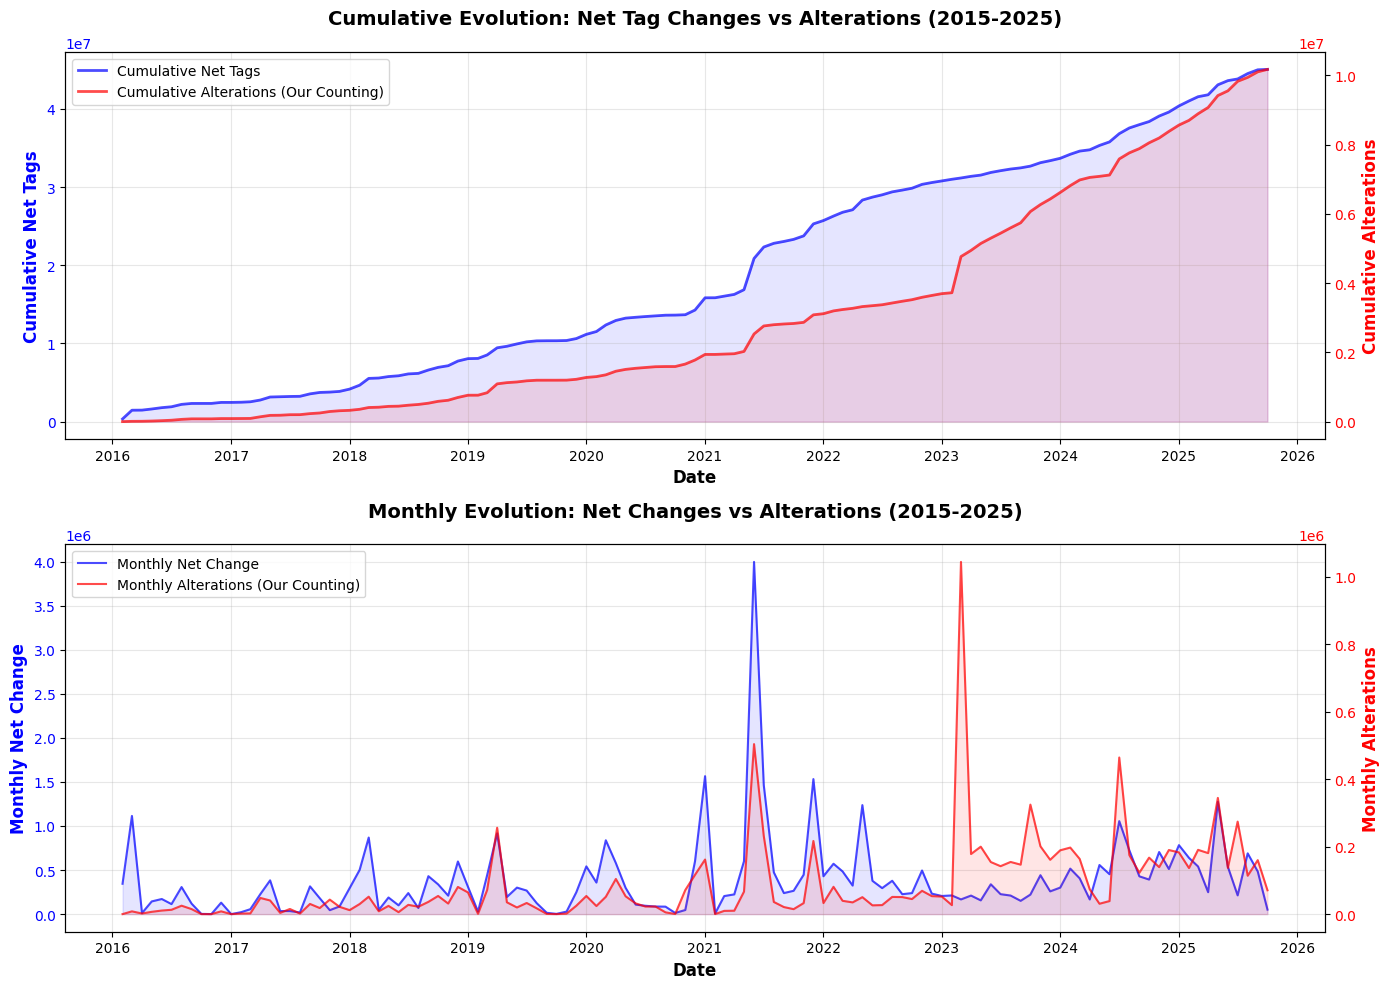


Comparison Statistics:
  Cumulative net tags: 45_049_693
  Cumulative alterations (our counting): 10_171_046
  Ratio (alterations/net): 0.2258

Monthly averages:
  Average tags added per month: 467,878
  Average tags removed per month: 82,838
  Average net change per month: 385,040
  Average alterations per month (our counting): 86,932


In [22]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ============================================================
# FIGURE 1: Cumulative Evolution - Net Changes
# ============================================================
ax1_twin = ax1.twinx()

# Plot cumulative net tags on left y-axis
line1 = ax1.plot(plot_data_net['month_date'], plot_data_net['cumulative'], 
                 'b-', linewidth=2, label='Cumulative Net Tags', alpha=0.7)
ax1.fill_between(plot_data_net['month_date'], 0, plot_data_net['cumulative'], 
                  alpha=0.1, color='blue')

# Plot cumulative alterations (our counting) on right y-axis
cumulative_alterations_net = comparison_net['total_alterations'].cumsum()
line2 = ax1_twin.plot(comparison_net['month_date'], cumulative_alterations_net, 
                      'r-', linewidth=2, label='Cumulative Alterations (Our Counting)', alpha=0.7)
ax1_twin.fill_between(comparison_net['month_date'], 0, cumulative_alterations_net, 
                       alpha=0.1, color='red')

# Formatting
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Net Tags', fontsize=12, fontweight='bold', color='blue')
ax1_twin.set_ylabel('Cumulative Alterations', fontsize=12, fontweight='bold', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.set_title('Cumulative Evolution: Net Tag Changes vs Alterations (2015-2025)', fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(1))

# Add combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

# ============================================================
# FIGURE 2: Monthly Evolution - Net Changes
# ============================================================
ax2_twin = ax2.twinx()

# Plot monthly net changes on left y-axis
line3 = ax2.plot(plot_data_net['month_date'], plot_data_net['net_change'], 
                 'b-', linewidth=1.5, label='Monthly Net Change', alpha=0.7)
# Use different fill for positive and negative values
ax2.fill_between(plot_data_net['month_date'], 0, plot_data_net['net_change'], 
                  where=(plot_data_net['net_change'] >= 0),
                  alpha=0.1, color='blue', interpolate=True)
ax2.fill_between(plot_data_net['month_date'], 0, plot_data_net['net_change'], 
                  where=(plot_data_net['net_change'] < 0),
                  alpha=0.1, color='orange', interpolate=True)

# Plot monthly alterations on right y-axis
line4 = ax2_twin.plot(comparison_net['month_date'], comparison_net['total_alterations'], 
                      'r-', linewidth=1.5, label='Monthly Alterations (Our Counting)', alpha=0.7)
ax2_twin.fill_between(comparison_net['month_date'], 0, comparison_net['total_alterations'], 
                       alpha=0.1, color='red')

# Formatting
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Monthly Net Change', fontsize=12, fontweight='bold', color='blue')
ax2_twin.set_ylabel('Monthly Alterations', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='blue')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2.set_title('Monthly Evolution: Net Changes vs Alterations (2015-2025)', fontsize=14, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))

# Add combined legend
lines = line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nComparison Statistics:")
print(f"  Cumulative net tags: {plot_data_net['cumulative'].iloc[-1]:_}")
print(f"  Cumulative alterations (our counting): {cumulative_alterations_net.iloc[-1]:_}")
print(f"  Ratio (alterations/net): {(cumulative_alterations_net.iloc[-1] / plot_data_net['cumulative'].iloc[-1]):.4f}")
print(f"\nMonthly averages:")
print(f"  Average tags added per month: {plot_data_net['added'].mean():,.0f}")
print(f"  Average tags removed per month: {plot_data_net['removed'].mean():,.0f}")
print(f"  Average net change per month: {plot_data_net['net_change'].mean():,.0f}")
print(f"  Average alterations per month (our counting): {comparison_net['total_alterations'].mean():,.0f}")

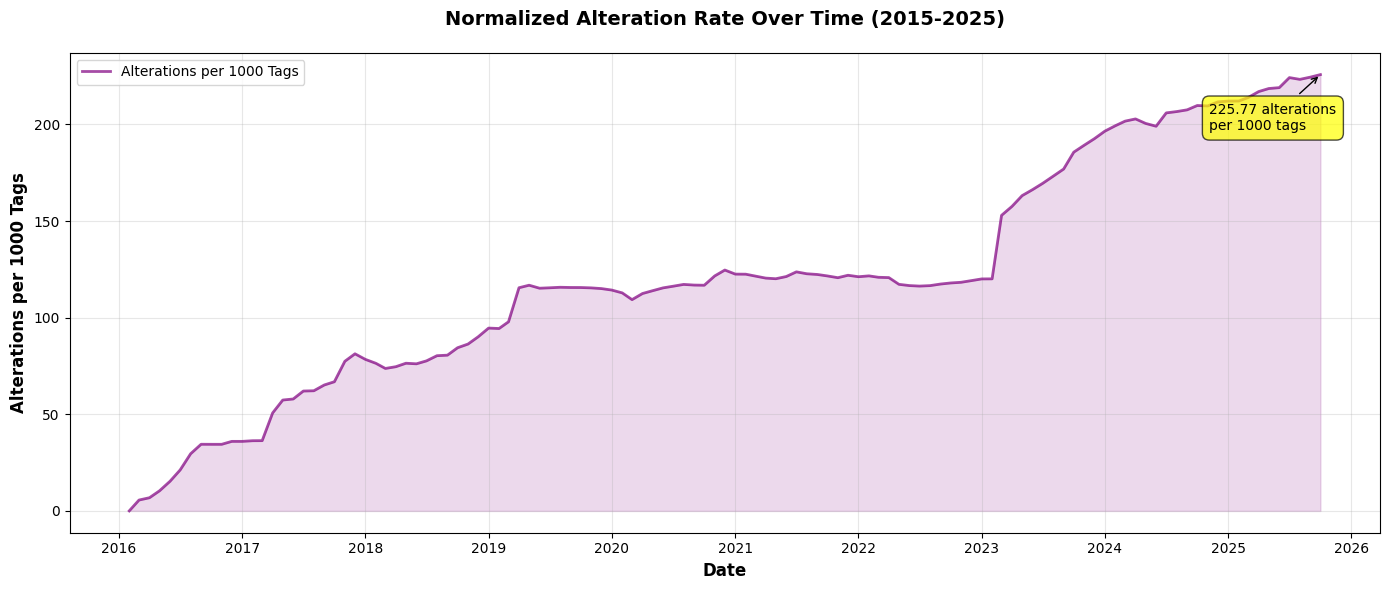


Normalized Alteration Rate Statistics:
  Initial rate (alterations per 1000 tags): 0.0000
  Final rate (alterations per 1000 tags): 225.7739
  Mean rate over period: 120.3923
  Median rate over period: 116.8636
  Maximum rate reached: 225.7739
  Maximum rate month: 2025-10


In [17]:
# Calculate normalized alteration rate per 1000 tags over time
comparison_net['cumulative_alterations'] = comparison_net['total_alterations'].cumsum()
comparison_net['alterations_per_1000_tags'] = (
    comparison_net['cumulative_alterations'] / comparison_net['cumulative'] * 1000
)

# Create plot showing normalized alteration rate over time
fig, ax = plt.subplots(figsize=(14, 6))

line = ax.plot(comparison_net['month_date'], comparison_net['alterations_per_1000_tags'], 
               'purple', linewidth=2, label='Alterations per 1000 Tags', alpha=0.7)
ax.fill_between(comparison_net['month_date'], 0, comparison_net['alterations_per_1000_tags'], 
                alpha=0.15, color='purple')

# Formatting
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Alterations per 1000 Tags', fontsize=12, fontweight='bold')
ax.set_title('Normalized Alteration Rate Over Time (2015-2025)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.legend(loc='upper left', fontsize=10)

# Add annotation for final rate
final_rate = comparison_net['alterations_per_1000_tags'].iloc[-1]
final_date = comparison_net['month_date'].iloc[-1]
ax.annotate(f'{final_rate:.2f} alterations\nper 1000 tags', 
            xy=(final_date, final_rate), 
            xytext=(-80, -40),
            textcoords='offset points',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print(f"\nNormalized Alteration Rate Statistics:")
print(f"  Initial rate (alterations per 1000 tags): {comparison_net['alterations_per_1000_tags'].iloc[0]:.4f}")
print(f"  Final rate (alterations per 1000 tags): {comparison_net['alterations_per_1000_tags'].iloc[-1]:.4f}")
print(f"  Mean rate over period: {comparison_net['alterations_per_1000_tags'].mean():.4f}")
print(f"  Median rate over period: {comparison_net['alterations_per_1000_tags'].median():.4f}")
print(f"  Maximum rate reached: {comparison_net['alterations_per_1000_tags'].max():.4f}")

# Find when max rate was reached
max_rate_idx = comparison_net['alterations_per_1000_tags'].idxmax()
max_rate_month = comparison_net.loc[max_rate_idx, 'month']
print(f"  Maximum rate month: {max_rate_month}")

## Repo vs Alterations

In [23]:
# Parse count_repos.log file
import re

repos_monthly_data = []

with open('../data/counts/count_repos.log', 'r') as f:
    # Skip lines until we find the header
    for line in f:
        if line.strip().startswith('Month'):
            # Skip the separator line
            next(f)
            break
    
    # Parse data lines
    for line in f:
        line = line.strip()
        if not line or line.startswith('Total origins'):
            break
        
        # Parse lines with format: "1970-01                    2               2"
        parts = line.split()
        if len(parts) >= 3:
            try:
                month = parts[0]
                new_origins = int(parts[1])
                cumulative = int(parts[2])
                
                repos_monthly_data.append({
                    'month': month,
                    'new_origins': new_origins,
                    'cumulative': cumulative
                })
            except (ValueError, IndexError):
                # Skip lines that don't match expected format
                continue

# Create DataFrame
repos_monthly_df = pd.DataFrame(repos_monthly_data)

print(f"Loaded {len(repos_monthly_df):_} months of data")
print(f"\nDate range: {repos_monthly_df['month'].iloc[0]} to {repos_monthly_df['month'].iloc[-1]}")
print(f"\nFirst few rows:")
print(repos_monthly_df.head())
print(f"\nLast few rows:")
print(repos_monthly_df.tail())

Loaded 121 months of data

Date range: 1970-01 to 2025-10

First few rows:
     month  new_origins  cumulative
0  1970-01            2           2
1  2015-07      1600216     1600218
2  2015-08      8284925     9885143
3  2015-09      1862626    11747769
4  2016-02         4188    11751957

Last few rows:
       month  new_origins  cumulative
116  2025-06      6164608   328172622
117  2025-07      5304642   333477264
118  2025-08      5638487   339115751
119  2025-09      5634401   344750152
120  2025-10      1517660   346267812


In [24]:

# Merge with monthly tags data
temporal_analysis_repo = repos_monthly_df.merge(
    alterations_by_month, 
    left_on='month', 
    right_on='alteration_month', 
    how='left'
)

temporal_analysis_repo['total_alterations'] = temporal_analysis_repo['total_alterations'].fillna(0).astype(int)
temporal_analysis_repo['annotated_alterations'] = temporal_analysis_repo['annotated_alterations'].fillna(0).astype(int)
temporal_analysis_repo['lightweight_alterations'] = temporal_analysis_repo['lightweight_alterations'].fillna(0).astype(int)

# Drop the duplicate month column
temporal_analysis_repo = temporal_analysis_repo.drop(columns=['alteration_month'], errors='ignore')

# print("=" * 70)
# print("TEMPORAL ANALYSIS (EXCLUDING NON-LEGIT)")
# print("=" * 70)
# print(f"Total months analyzed: {len(temporal_analysis_repo):_}")
# print(f"Months with alterations: {(temporal_analysis_repo['total_alterations'] > 0).sum():_}")
# print(f"\nSummary statistics (normalized per 1000 EXISTING tags):")
# print(f"  Mean alterations per 1000 tags: {temporal_analysis_repo['alterations_per_1000'].mean():.4f}")
# print(f"  Median alterations per 1000 tags: {temporal_analysis_repo['alterations_per_1000'].median():.4f}")
# print(f"  Max alterations per 1000 tags: {temporal_analysis_repo['alterations_per_1000'].max():.4f}")
# print(f"\nFinal cumulative totals:")
# print(f"  Total tags existing: {temporal_analysis_repo['cumulative_total'].iloc[-1]:_}")
# print(f"  Lightweight: {temporal_analysis_repo['cumulative_lightweight'].iloc[-1]:_}")
# print(f"  Annotated: {temporal_analysis_repo['cumulative_annotated'].iloc[-1]:_}")
# print("\n" + "=" * 70)

temporal_analysis_repo.head(10)

,month,new_origins,cumulative,total_alterations,annotated_alterations,lightweight_alterations
0,1970-01,2,2,0,0,0
1,2015-07,1600216,1600218,0,0,0
2,2015-08,8284925,9885143,0,0,0
3,2015-09,1862626,11747769,0,0,0
4,2016-02,4188,11751957,0,0,0
5,2016-03,129384,11881341,8196,2134,6062
6,2016-04,1817281,13698622,1829,638,1191
7,2016-05,2803444,16502066,6809,2751,4058
8,2016-06,1185056,17687122,10588,4300,6288
9,2016-07,10124,17697246,12867,9970,2897


In [25]:
# Prepare data for plotting: filter to 2015-2026 and add datetime column
temporal_analysis_repo['month_date'] = pd.to_datetime(temporal_analysis_repo['month'] + '-01')

plot_data_repo_alt = temporal_analysis_repo[
    (temporal_analysis_repo['month_date'] >= '2015-09-17') &
    (temporal_analysis_repo['month_date'] < '2026-01-01')
].copy()

print(f"Plotting repos vs alterations from {plot_data_repo_alt['month_date'].min().strftime('%Y-%m')} to {plot_data_repo_alt['month_date'].max().strftime('%Y-%m')}")
print(f"Total months in range: {len(plot_data_repo_alt)}")
print(f"\nSummary:")
print(f"  Total new origins in period: {plot_data_repo_alt['new_origins'].sum():_}")
print(f"  Total alterations in period: {plot_data_repo_alt['total_alterations'].sum():_}")
print(f"  Final cumulative origins: {plot_data_repo_alt['cumulative'].iloc[-1]:_}")
print(f"  Final cumulative alterations: {plot_data_repo_alt['total_alterations'].cumsum().iloc[-1]:_}")

Plotting repos vs alterations from 2016-02 to 2025-10
Total months in range: 117

Summary:
  Total new origins in period: 334_520_043
  Total alterations in period: 10_171_046
  Final cumulative origins: 346_267_812
  Final cumulative alterations: 10_171_046


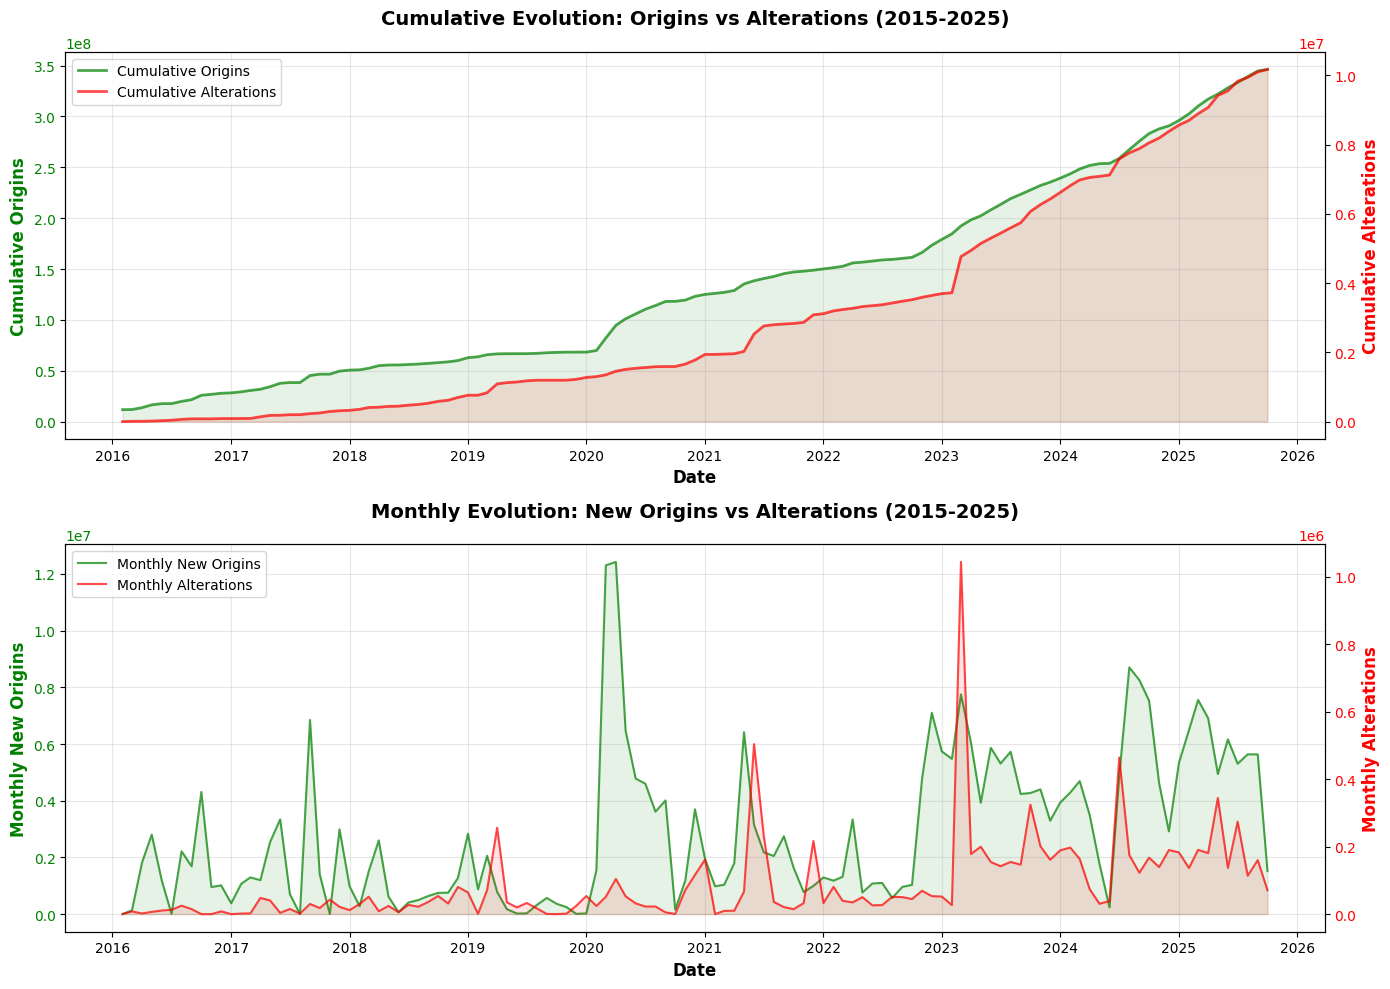


Final Statistics:
  Cumulative origins: 346_267_812
  Cumulative alterations: 10_171_046
  Alteration rate (alterations per origin): 0.0294
  Origins with alterations: 188_713
  Proportion of origins with alterations: 0.0545%


In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ============================================================
# FIGURE 1: Cumulative Evolution - Origins vs Alterations
# ============================================================
ax1_twin = ax1.twinx()

# Plot cumulative origins on left y-axis
line1 = ax1.plot(plot_data_repo_alt['month_date'], plot_data_repo_alt['cumulative'], 
                 'g-', linewidth=2, label='Cumulative Origins', alpha=0.7)
ax1.fill_between(plot_data_repo_alt['month_date'], 0, plot_data_repo_alt['cumulative'], 
                  alpha=0.1, color='green')

# Plot cumulative alterations on right y-axis
cumulative_alterations_repo = plot_data_repo_alt['total_alterations'].cumsum()
line2 = ax1_twin.plot(plot_data_repo_alt['month_date'], cumulative_alterations_repo, 
                      'r-', linewidth=2, label='Cumulative Alterations', alpha=0.7)
ax1_twin.fill_between(plot_data_repo_alt['month_date'], 0, cumulative_alterations_repo, 
                       alpha=0.1, color='red')

# Formatting
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Origins', fontsize=12, fontweight='bold', color='green')
ax1_twin.set_ylabel('Cumulative Alterations', fontsize=12, fontweight='bold', color='red')
ax1.tick_params(axis='y', labelcolor='green')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.set_title('Cumulative Evolution: Origins vs Alterations (2015-2025)', fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(1))

# Add combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

# ============================================================
# FIGURE 2: Monthly Evolution - New Origins vs Alterations
# ============================================================
ax2_twin = ax2.twinx()

# Plot monthly new origins on left y-axis
line3 = ax2.plot(plot_data_repo_alt['month_date'], plot_data_repo_alt['new_origins'], 
                 'g-', linewidth=1.5, label='Monthly New Origins', alpha=0.7)
ax2.fill_between(plot_data_repo_alt['month_date'], 0, plot_data_repo_alt['new_origins'], 
                  alpha=0.1, color='green')

# Plot monthly alterations on right y-axis
line4 = ax2_twin.plot(plot_data_repo_alt['month_date'], plot_data_repo_alt['total_alterations'], 
                      'r-', linewidth=1.5, label='Monthly Alterations', alpha=0.7)
ax2_twin.fill_between(plot_data_repo_alt['month_date'], 0, plot_data_repo_alt['total_alterations'], 
                       alpha=0.1, color='red')

# Formatting
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Monthly New Origins', fontsize=12, fontweight='bold', color='green')
ax2_twin.set_ylabel('Monthly Alterations', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='green')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2.set_title('Monthly Evolution: New Origins vs Alterations (2015-2025)', fontsize=14, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))

# Add combined legend
lines = line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nFinal Statistics:")
print(f"  Cumulative origins: {plot_data_repo_alt['cumulative'].iloc[-1]:_}")
print(f"  Cumulative alterations: {cumulative_alterations_repo.iloc[-1]:_}")
print(f"  Alteration rate (alterations per origin): {(cumulative_alterations_repo.iloc[-1] / plot_data_repo_alt['cumulative'].iloc[-1]):.4f}")
print(f"  Origins with alterations: {df['origin_url'].nunique():_}")
print(f"  Proportion of origins with alterations: {(df['origin_url'].nunique() / plot_data_repo_alt['cumulative'].iloc[-1] * 100):.4f}%")

In [28]:
# Compute Pearson correlation coefficient between monthly new origins and monthly alterations
from scipy import stats

# Get the two time series
monthly_new_origins = plot_data_repo_alt['new_origins'].values
monthly_alterations = plot_data_repo_alt['total_alterations'].values

# Compute Pearson correlation
pearson_r, pearson_p = stats.pearsonr(monthly_new_origins, monthly_alterations)

# Compute Spearman correlation (rank-based, more robust to outliers)
spearman_r, spearman_p = stats.spearmanr(monthly_new_origins, monthly_alterations)

print("=" * 70)
print("CORRELATION ANALYSIS: Monthly New Origins vs Monthly Alterations")
print("=" * 70)
print(f"\nPearson Correlation Coefficient:")
print(f"  r = {pearson_r:.4f}")
print(f"  p-value = {pearson_p:.4e}")
print(f"  Interpretation: {'Significant' if pearson_p < 0.05 else 'Not significant'} at α=0.05")
print(f"  Strength: ", end="")
if abs(pearson_r) < 0.3:
    print("Weak correlation")
elif abs(pearson_r) < 0.7:
    print("Moderate correlation")
else:
    print("Strong correlation")

print(f"\nSpearman Correlation Coefficient (rank-based):")
print(f"  ρ = {spearman_r:.4f}")
print(f"  p-value = {spearman_p:.4e}")
print(f"  Interpretation: {'Significant' if spearman_p < 0.05 else 'Not significant'} at α=0.05")

print(f"\nCoefficient of Determination (R²):")
print(f"  R² = {pearson_r**2:.4f}")
print(f"  Meaning: {pearson_r**2*100:.2f}% of variance in one variable is explained by the other")

print("\n" + "=" * 70)

CORRELATION ANALYSIS: Monthly New Origins vs Monthly Alterations

Pearson Correlation Coefficient:
  r = 0.4217
  p-value = 2.1936e-06
  Interpretation: Significant at α=0.05
  Strength: Moderate correlation

Spearman Correlation Coefficient (rank-based):
  ρ = 0.5723
  p-value = 1.5752e-11
  Interpretation: Significant at α=0.05

Coefficient of Determination (R²):
  R² = 0.1778
  Meaning: 17.78% of variance in one variable is explained by the other



TEMPORAL EVOLUTION OF CORRELATION SIGNIFICANCE

First statistically significant (p < 0.05):
  Date: 2023-03
  After including 86 months of data
  Pearson r = 0.2900
  p-value = 6.7511e-03

Progression around significance threshold:
  2023-01: r=0.1547, p=1.6004e-01 - Not significant
  2023-02: r=0.1483, p=1.7546e-01 - Not significant
  2023-03: r=0.2900, p=6.7511e-03 - *** FIRST SIGNIFICANT ***
  2023-04: r=0.3019, p=4.4915e-03 - ✓ Significant
  2023-05: r=0.3080, p=3.5063e-03 - ✓ Significant



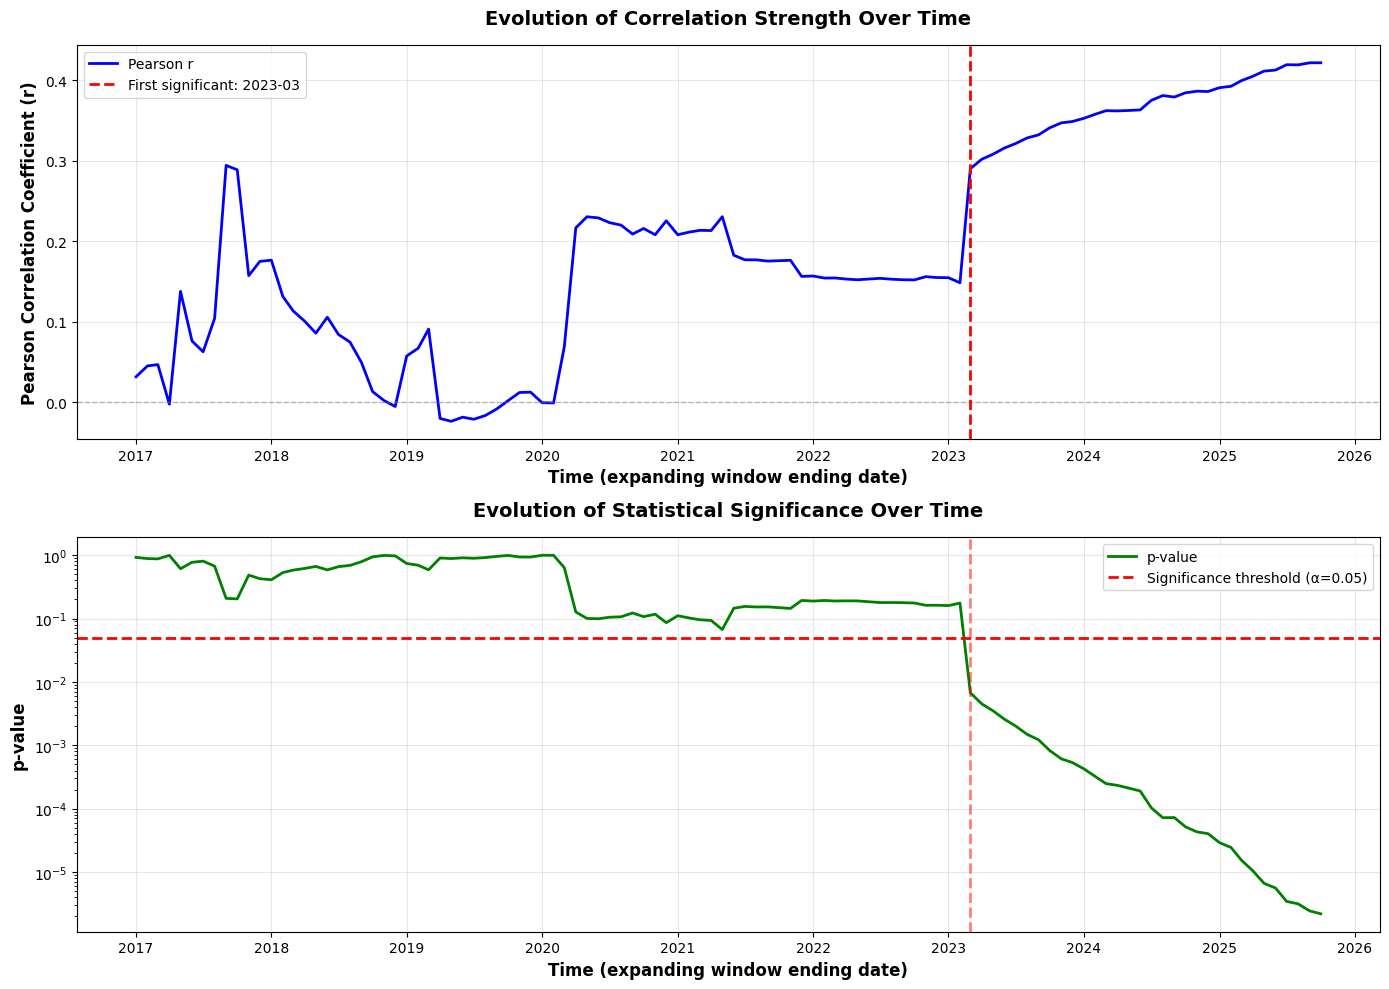

In [29]:
# Expanding window analysis: when does the correlation become significant?
# Start with the first 12 months and expand incrementally

min_window = 12  # Minimum months needed for meaningful correlation

expanding_results = []

for i in range(min_window, len(plot_data_repo_alt) + 1):
    # Get data up to month i
    window_origins = plot_data_repo_alt['new_origins'].iloc[:i].values
    window_alterations = plot_data_repo_alt['total_alterations'].iloc[:i].values
    
    # Compute correlation for this window
    r, p = stats.pearsonr(window_origins, window_alterations)
    
    expanding_results.append({
        'months_included': i,
        'end_date': plot_data_repo_alt['month_date'].iloc[i-1],
        'end_month': plot_data_repo_alt['month'].iloc[i-1],
        'pearson_r': r,
        'p_value': p,
        'is_significant': p < 0.05
    })

expanding_df = pd.DataFrame(expanding_results)

# Find when it first becomes significant
first_significant = expanding_df[expanding_df['is_significant']].iloc[0] if expanding_df['is_significant'].any() else None

print("=" * 70)
print("TEMPORAL EVOLUTION OF CORRELATION SIGNIFICANCE")
print("=" * 70)

if first_significant is not None:
    print(f"\nFirst statistically significant (p < 0.05):")
    print(f"  Date: {first_significant['end_month']}")
    print(f"  After including {first_significant['months_included']} months of data")
    print(f"  Pearson r = {first_significant['pearson_r']:.4f}")
    print(f"  p-value = {first_significant['p_value']:.4e}")
    
    # Show progression around that point
    idx = first_significant.name
    print(f"\nProgression around significance threshold:")
    for i in range(max(0, idx-2), min(len(expanding_df), idx+3)):
        row = expanding_df.iloc[i]
        sig_marker = "*** FIRST SIGNIFICANT ***" if i == idx else ("✓ Significant" if row['is_significant'] else "Not significant")
        print(f"  {row['end_month']}: r={row['pearson_r']:6.4f}, p={row['p_value']:.4e} - {sig_marker}")
else:
    print("\nCorrelation never reached statistical significance in the time period analyzed.")

print("\n" + "=" * 70)

# Plot the evolution
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Evolution of correlation coefficient
ax1.plot(expanding_df['end_date'], expanding_df['pearson_r'], 'b-', linewidth=2, label='Pearson r')
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
if first_significant is not None:
    ax1.axvline(x=first_significant['end_date'], color='red', linestyle='--', linewidth=2, 
                label=f'First significant: {first_significant["end_month"]}')
ax1.set_xlabel('Time (expanding window ending date)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax1.set_title('Evolution of Correlation Strength Over Time', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2: Evolution of p-value
ax2.plot(expanding_df['end_date'], expanding_df['p_value'], 'g-', linewidth=2, label='p-value')
ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Significance threshold (α=0.05)')
if first_significant is not None:
    ax2.axvline(x=first_significant['end_date'], color='red', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Time (expanding window ending date)', fontsize=12, fontweight='bold')
ax2.set_ylabel('p-value', fontsize=12, fontweight='bold')
ax2.set_title('Evolution of Statistical Significance Over Time', fontsize=14, fontweight='bold', pad=15)
ax2.set_yscale('log')  # Log scale to better see p-value changes
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

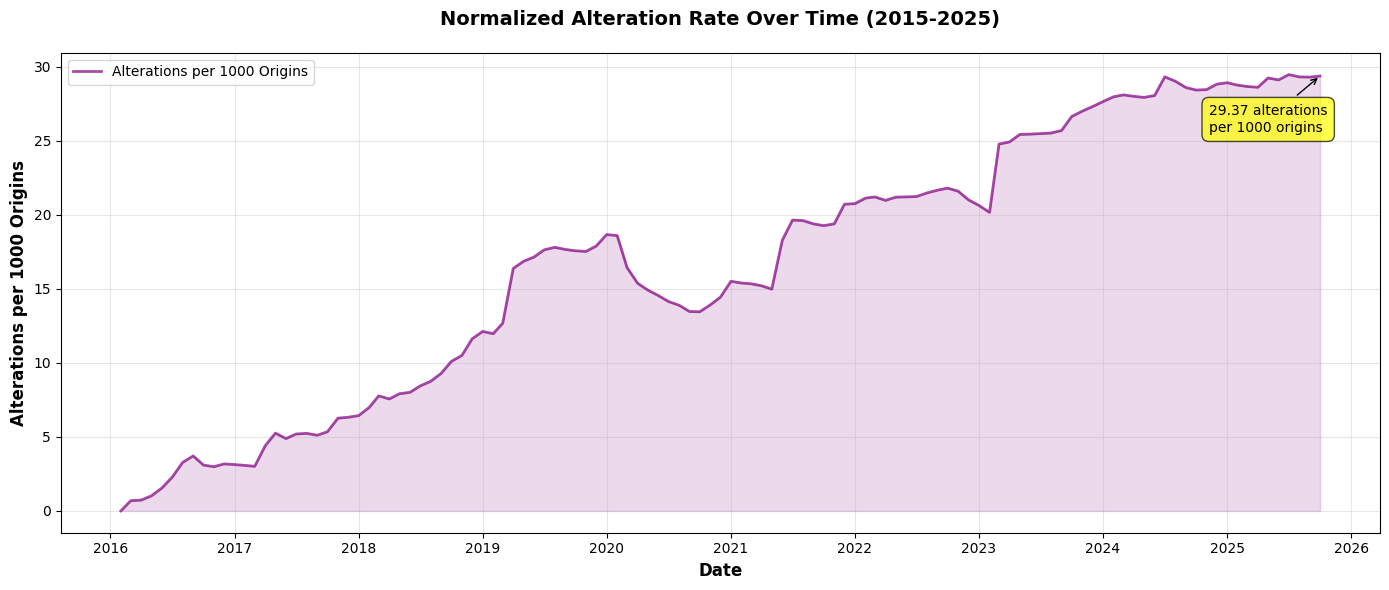


Normalized Alteration Rate Statistics:
  Initial rate (alteration per 1000 origins): 0.0000
  Final rate (alterations per 1000 origins): 29.3734
  Mean rate over period: 16.7193
  Median rate over period: 17.6315
  Maximum rate reached: 29.4671
  Maximum rate month: 2025-07


In [27]:
# Calculate alterations per 1000 origins over time
plot_data_repo_alt['cumulative_alterations'] = plot_data_repo_alt['total_alterations'].cumsum()
plot_data_repo_alt['alterations_per_1000_origins'] = (
    plot_data_repo_alt['cumulative_alterations'] / plot_data_repo_alt['cumulative'] * 1000
)

# Create plot showing normalized alteration rate over time
fig, ax = plt.subplots(figsize=(14, 6))

line = ax.plot(plot_data_repo_alt['month_date'], plot_data_repo_alt['alterations_per_1000_origins'], 
               'purple', linewidth=2, label='Alterations per 1000 Origins', alpha=0.7)
ax.fill_between(plot_data_repo_alt['month_date'], 0, plot_data_repo_alt['alterations_per_1000_origins'], 
                alpha=0.15, color='purple')

# Formatting
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Alterations per 1000 Origins', fontsize=12, fontweight='bold')
ax.set_title('Normalized Alteration Rate Over Time (2015-2025)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.legend(loc='upper left', fontsize=10)

# Add annotation for final rate
final_rate = plot_data_repo_alt['alterations_per_1000_origins'].iloc[-1]
final_date = plot_data_repo_alt['month_date'].iloc[-1]
ax.annotate(f'{final_rate:.2f} alterations\nper 1000 origins', 
            xy=(final_date, final_rate), 
            xytext=(-80, -40),
            textcoords='offset points',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print(f"\nNormalized Alteration Rate Statistics:")
print(f"  Initial rate (alteration per 1000 origins): {plot_data_repo_alt['alterations_per_1000_origins'].iloc[0]:.4f}")
print(f"  Final rate (alterations per 1000 origins): {plot_data_repo_alt['alterations_per_1000_origins'].iloc[-1]:.4f}")
print(f"  Mean rate over period: {plot_data_repo_alt['alterations_per_1000_origins'].mean():.4f}")
print(f"  Median rate over period: {plot_data_repo_alt['alterations_per_1000_origins'].median():.4f}")
print(f"  Maximum rate reached: {plot_data_repo_alt['alterations_per_1000_origins'].max():.4f}")

# Find when max rate was reached
max_rate_idx = plot_data_repo_alt['alterations_per_1000_origins'].idxmax()
max_rate_month = plot_data_repo_alt.loc[max_rate_idx, 'month']
print(f"  Maximum rate month: {max_rate_month}")

# Taxonomy

In [27]:
conn = sqlite3.connect('../data/tags_alterations_full_2025-10_v2.db')
diffs = pd.read_sql_query("SELECT * FROM tag_diffs", conn)
# files = pd.read_sql_query("SELECT * FROM tag_file_diffs", conn)

# print(f"Loaded {len(files):_} rows from database")
print(f"Loaded {len(diffs):_} rows from database")

Loaded 1_129_593 rows from database


In [28]:
diffs[diffs['rel_message_differs'].notna()].head(5)

,origin_url,tag_name,tag_type,old_snapshot,altering_snapshot,old_snap_timestamp,old_release_swhid,new_release_swhid,old_revision_swhid,new_revision_swhid,old_directory_swhid,new_directory_swhid,rel_message_differs,rel_author_differs,rel_author_timestamp_differs,rev_message_differs,rev_author_differs,rev_committer_differs,rev_author_timestamp_differs,rev_committer_timestamp_differs,dir_added,dir_deleted,dir_modified,dir_renamed
23,https://github.com/netsecsp/aftpx,refs/tags/1.2,annotated,swh:1:snp:904b1019f5dd78512b7243dbbda36ec5a84d0b2a,swh:1:snp:3a52110e1afc36346e5527be9ead961263dde088,1652829509,swh:1:rel:a737d81fe8a3478a062cd66e7f91a48aee0700f6,swh:1:rel:43efe98c75aa10c233f80dc782071a2d0321defe,swh:1:rev:3d97b7f47634df91fcaa6c617613f2f0f171d384,swh:1:rev:7b76beb54d8d80161cd06a346700b6906313a632,swh:1:dir:d9cd4b4fcf23f4429c071597f43276204dc7cdb7,swh:1:dir:72201067c1d5cbcf97f868d6003be04f2921fba3,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,2.0,2.0,81.0,0.0
24,https://github.com/exploratory-io/exploratory_func,refs/tags/v9.0.4,annotated,swh:1:snp:6e29672775e540b94eb7eceb90ae429407d52149,swh:1:snp:eedde52d07f0ec818a36fb712329dd4473cdcdd6,1709319338,swh:1:rel:3dc0e2da0b2ff65b3b8cfebff9d8d590bdc28366,swh:1:rel:aa9d6b69577021b1aeb3802e2ebd0bff6beb2380,swh:1:rev:6f16e42648dd6b2aa20adf7bd21ba05809beb521,swh:1:rev:67f5e3eb3c11c3ec94f9ca7b107beec715959777,swh:1:dir:20090e6f09b35a1c653e8cc65af9ccc2c42d2895,swh:1:dir:8db796a63b61f2cc1a52a53b3bfb4e7356467947,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
55,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.8.2,annotated,swh:1:snp:4631c43cdc09ed21389ea06cd43ad988ab5041b6,swh:1:snp:faa054d9b46d6609ec763f84af3b37141f5c16a5,1666003050,swh:1:rel:187c2101fc1e5b1c4b04489a383c820b9588933e,swh:1:rel:cb29d1ae31ddce2e021a5d4b06b202a9d620c16a,swh:1:rev:511eb592045ff064c0b0fac4b4c09fa42c4e0551,swh:1:rev:7b16607ec0bbd65e65d3f4b625b529fb77cfc281,swh:1:dir:effb81e567c548e781a2af75e83e6d7955e67c2c,swh:1:dir:e9a763df018b77a35c813e0d43ff62f45e5ba862,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,23.0,0.0,207.0,0.0
56,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.7.4,annotated,swh:1:snp:26bfb178d3f536a32fdc73a580f2d19536546609,swh:1:snp:c1bfc417776f6953aff26ef2600d63958cce1940,1643061100,swh:1:rel:aef92a8b2b184e6347065b045527de71519ae4a6,swh:1:rel:cbf0ab0a978e3cee8060d01129a42e079e618117,swh:1:rev:d543b7d0c39818bf540fbbc866642c0a7d5eefb4,swh:1:rev:0ebadd8441f7c13677db75ee03fcc3320b143b00,swh:1:dir:2b217826ccc3dfa6fea64e4918c24959da8ea6d5,swh:1:dir:e864a8962ff5290a191534da3506be46fb72fb16,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,3.0,0.0
57,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.6.5,annotated,swh:1:snp:222e793009529ccda47ee5a06f6fda7e21019b73,swh:1:snp:c1bfc417776f6953aff26ef2600d63958cce1940,1624392023,swh:1:rel:fd2f90d38ecb1de4c84af0f582d2457086715d6e,swh:1:rel:7719a776db33e95b3f7f0349ad704805a208dc06,swh:1:rev:8c7b7408af11fef73875e72146ce969f9fb7a75c,swh:1:rev:eb447ab7a232039600583afd074339ec345e50e6,swh:1:dir:e208f8a221391409745e506a210545b8b1532d68,swh:1:dir:7ddd936b243a754a807f7a89a689d9680a5aa6ee,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [29]:
# Compute statistics for diffs dataframe

# 1. Identify rows with rel changes (sum of differs >= 1)
rel_cols = ['rel_message_differs', 'rel_author_differs', 'rel_author_timestamp_differs']
diffs['has_rel_changes'] = diffs[rel_cols].notna().sum(axis=1) >= 1

# 2. Identify rows with rev changes (sum of differs >= 1)
rev_cols = ['rev_message_differs', 'rev_author_differs', 'rev_committer_differs', 
            'rev_author_timestamp_differs', 'rev_committer_timestamp_differs']
diffs['has_rev_changes'] = diffs[rev_cols].notna().sum(axis=1) >= 1

# 3. Identify rows with dir changes (only when old_directory != new_directory)
diffs['has_dir_changes'] = (diffs['old_directory_swhid'] != diffs['new_directory_swhid']) & \
                            (diffs['old_directory_swhid'].notna()) & \
                            (diffs['new_directory_swhid'].notna())

# Count rows with each type of change
total_rows = len(diffs)
rel_count = diffs['has_rel_changes'].sum()
rev_count = diffs['has_rev_changes'].sum()
dir_count = diffs['has_dir_changes'].sum()

print("=" * 60)
print("CHANGES IN DIFFS DATAFRAME")
print("=" * 60)
print(f"Total rows: {total_rows:_}")
print()
print(f"Release changes:   {rel_count:_} rows ({rel_count/total_rows*100:.2f}%)")
print(f"Revision changes:  {rev_count:_} rows ({rev_count/total_rows*100:.2f}%)")
print(f"Directory changes: {dir_count:_} rows ({dir_count/total_rows*100:.2f}%)")
print()

# Directory statistics (only for rows where directories differ)
dir_changed_rows = diffs[diffs['has_dir_changes']]
print("=" * 60)
print("DIRECTORY CHANGE STATISTICS")
print("(Only for rows where old_directory != new_directory)")
print("=" * 60)

if len(dir_changed_rows) > 0:
    dir_stats_cols = ['dir_added', 'dir_deleted', 'dir_modified', 'dir_renamed']
    for col in dir_stats_cols:
        mean_val = dir_changed_rows[col].mean()
        median_val = dir_changed_rows[col].median()
        total_val = dir_changed_rows[col].sum()
        print(f"\n{col}:")
        print(f"  Mean:   {mean_val:.2f}")
        print(f"  Median: {median_val:.0f}")
        print(f"  Total:  {total_val:_}")
else:
    print("No directory changes found")
    
print("\n" + "=" * 60)

CHANGES IN DIFFS DATAFRAME
Total rows: 1_129_593

Release changes:   184_888 rows (16.37%)
Revision changes:  654_004 rows (57.90%)
Directory changes: 441_082 rows (39.05%)

DIRECTORY CHANGE STATISTICS
(Only for rows where old_directory != new_directory)

dir_added:
  Mean:   443.84
  Median: 1
  Total:  195_770_425.0

dir_deleted:
  Mean:   136.00
  Median: 1
  Total:  59_989_137.0

dir_modified:
  Mean:   499.45
  Median: 5
  Total:  220_297_582.0

dir_renamed:
  Mean:   41.45
  Median: 0
  Total:  18_283_017.0



In [30]:
# Detailed statistics for each type of change

print("=" * 70)
print("DETAILED RELEASE CHANGE STATISTICS")
print("=" * 70)
print(f"Total rows with release changes: {rel_count:_}\n")

rel_cols = ['rel_message_differs', 'rel_author_differs', 'rel_author_timestamp_differs']
for col in rel_cols:
    count = ((diffs[col].notna()) & (diffs[col] > 0)).sum()
    pct_of_rel = (count / rel_count * 100) if rel_count > 0 else 0
    pct_of_total = count / total_rows * 100
    print(f"{col}:")
    print(f"  Count: {count:_}")
    print(f"  {pct_of_rel:.2f}% of rows with rel changes")
    print(f"  {pct_of_total:.2f}% of total diffs rows")
    print()

print("=" * 70)
print("DETAILED REVISION CHANGE STATISTICS")
print("=" * 70)
print(f"Total rows with revision changes: {rev_count:_}\n")

rev_cols = ['rev_message_differs', 'rev_author_differs', 'rev_committer_differs', 
            'rev_author_timestamp_differs', 'rev_committer_timestamp_differs']
for col in rev_cols:
    count = ((diffs[col].notna()) & (diffs[col] > 0)).sum()
    pct_of_rev = (count / rev_count * 100) if rev_count > 0 else 0
    pct_of_total = count / total_rows * 100
    print(f"{col}:")
    print(f"  Count: {count:_}")
    print(f"  {pct_of_rev:.2f}% of rows with rev changes")
    print(f"  {pct_of_total:.2f}% of total diffs rows")
    print()

print("=" * 70)
print("DETAILED DIRECTORY CHANGE STATISTICS")
print("=" * 70)
print(f"Total rows with directory changes: {dir_count:_}\n")

dir_cols = ['dir_added', 'dir_deleted', 'dir_modified', 'dir_renamed']
for col in dir_cols:
    # Count rows where this column > 0
    count = (dir_changed_rows[col] > 0).sum()
    pct_of_dir = (count / dir_count * 100) if dir_count > 0 else 0
    pct_of_total = count / total_rows * 100
    print(f"{col} (rows with at least 1 file):")
    print(f"  Count: {count:_}")
    print(f"  {pct_of_dir:.2f}% of rows with dir changes")
    print(f"  {pct_of_total:.2f}% of total diffs rows")
    print()
    
print("=" * 70)

DETAILED RELEASE CHANGE STATISTICS
Total rows with release changes: 184_888

rel_message_differs:
  Count: 39_618
  21.43% of rows with rel changes
  3.51% of total diffs rows

rel_author_differs:
  Count: 28_069
  15.18% of rows with rel changes
  2.48% of total diffs rows

rel_author_timestamp_differs:
  Count: 79_590
  43.05% of rows with rel changes
  7.05% of total diffs rows

DETAILED REVISION CHANGE STATISTICS
Total rows with revision changes: 654_004

rev_message_differs:
  Count: 309_313
  47.30% of rows with rev changes
  27.38% of total diffs rows

rev_author_differs:
  Count: 186_595
  28.53% of rows with rev changes
  16.52% of total diffs rows

rev_committer_differs:
  Count: 181_533
  27.76% of rows with rev changes
  16.07% of total diffs rows

rev_author_timestamp_differs:
  Count: 333_128
  50.94% of rows with rev changes
  29.49% of total diffs rows

rev_committer_timestamp_differs:
  Count: 354_048
  54.14% of rows with rev changes
  31.34% of total diffs rows

DETA

# Popularity

In [33]:
stars = pd.read_pickle("/home/infres/rapaport/datasets/github-stars/github-stars.pkl")

In [34]:
# Define star ranges
def categorize_stars(stars):
    if pd.isna(stars):
        return 'Unknown'
    elif stars <= 1:
        return '0-1 star'
    elif stars <= 10:
        return '2-10 stars'
    elif stars <= 100:
        return '11-100 stars'
    elif stars <= 500:
        return '101-500 stars'
    else:
        return '500+ stars'

df['star_range'] = df['stars'].apply(categorize_stars)

# Group by star range
star_stats = df.groupby('star_range').agg({
    'tag_name': 'count',    
    'origin_url': 'nunique',
    'stars': ['min', 'max', 'mean', 'median']
}).reset_index()

# Flatten column names
star_stats.columns = ['star_range', 'total_alterations', 'unique_origins', 'min_stars', 'max_stars', 'mean_stars', 'median_stars']

# Order by star range
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
star_stats['order'] = star_stats['star_range'].apply(lambda x: star_order.index(x) if x in star_order else 999)
star_stats = star_stats.sort_values('order').drop(columns=['order'])

# Calculate proportions
star_stats['pct_alterations'] = (star_stats['total_alterations'] / star_stats['total_alterations'].sum() * 100)
star_stats['pct_origins'] = (star_stats['unique_origins'] / star_stats['unique_origins'].sum() * 100)

print("=" * 80)
print("ALTERATIONS BY REPOSITORY STAR COUNT")
print("=" * 80)
print(f"Total alterations analyzed: {len(df):_}")
print(f"Total unique origins: {df['origin_url'].nunique():_}")
print()

for idx, row in star_stats.iterrows():
    print(f"\n{row['star_range']}:")
    print(f"  Alterations: {row['total_alterations']:_} ({row['pct_alterations']:.2f}%)")
    print(f"  Unique origins: {row['unique_origins']:_} ({row['pct_origins']:.2f}%)")
    if row['star_range'] != 'Unknown':
        print(f"  Star range: {row['min_stars']:.0f} - {row['max_stars']:.0f}")
        print(f"  Mean stars: {row['mean_stars']:.1f}")
        print(f"  Median stars: {row['median_stars']:.0f}")
    print(f"  Avg alterations per origin: {row['total_alterations'] / row['unique_origins']:.2f}")

print("\n" + "=" * 80)

ALTERATIONS BY REPOSITORY STAR COUNT
Total alterations analyzed: 10_815_603
Total unique origins: 227_635


0-1 star:
  Alterations: 7_849_587 (72.58%)
  Unique origins: 120_152 (52.78%)
  Star range: 0 - 1
  Mean stars: 0.1
  Median stars: 0
  Avg alterations per origin: 65.33

2-10 stars:
  Alterations: 384_288 (3.55%)
  Unique origins: 25_537 (11.22%)
  Star range: 2 - 10
  Mean stars: 4.8
  Median stars: 4
  Avg alterations per origin: 15.05

11-100 stars:
  Alterations: 392_570 (3.63%)
  Unique origins: 19_629 (8.62%)
  Star range: 11 - 100
  Mean stars: 32.6
  Median stars: 23
  Avg alterations per origin: 20.00

101-500 stars:
  Alterations: 253_776 (2.35%)
  Unique origins: 7_864 (3.45%)
  Star range: 101 - 500
  Mean stars: 232.1
  Median stars: 195
  Avg alterations per origin: 32.27

500+ stars:
  Alterations: 636_681 (5.89%)
  Unique origins: 6_780 (2.98%)
  Star range: 501 - 216640
  Mean stars: 8968.1
  Median stars: 904
  Avg alterations per origin: 93.91

Unknown:
  Alt

In [35]:
# Compute proportion of origins with at least 1 alteration per star range

# Categorize all origins in the stars dataset by star range
stars['star_range'] = stars['stars'].apply(categorize_stars)

# Count total origins per star range (from the full stars dataset)
total_origins_per_range = stars.groupby('star_range').size().reset_index(name='total_origins')

# Origins with at least 1 alteration per star range (from star_stats)
origins_with_alterations = star_stats[['star_range', 'unique_origins']].copy()
origins_with_alterations.columns = ['star_range', 'origins_with_alterations']

# Merge the two
proportion_analysis = total_origins_per_range.merge(origins_with_alterations, on='star_range', how='left')
proportion_analysis['origins_with_alterations'] = proportion_analysis['origins_with_alterations'].fillna(0).astype(int)

# Calculate proportion
proportion_analysis['proportion_with_alterations'] = (
    proportion_analysis['origins_with_alterations'] / proportion_analysis['total_origins'] * 100
)

# Order by star range
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
proportion_analysis['order'] = proportion_analysis['star_range'].apply(lambda x: star_order.index(x) if x in star_order else 999)
proportion_analysis = proportion_analysis.sort_values('order').drop(columns=['order'])

print("=" * 90)
print("PROPORTION OF ORIGINS WITH AT LEAST 1 ALTERATION BY STAR RANGE")
print("=" * 90)
print(f"Total unique origins in stars dataset: {len(stars):_}")
print(f"Total unique origins with alterations: {df['origin_url'].nunique():_}")
print()

for idx, row in proportion_analysis.iterrows():
    print(f"\n{row['star_range']}:")
    print(f"  Total origins in range: {row['total_origins']:_}")
    print(f"  Origins with ≥1 alteration: {row['origins_with_alterations']:_}")
    print(f"  Proportion: {row['proportion_with_alterations']:.4f}%")

print("\n" + "=" * 90)

# Display as dataframe
proportion_analysis[['star_range', 'total_origins', 'origins_with_alterations', 'proportion_with_alterations']]

PROPORTION OF ORIGINS WITH AT LEAST 1 ALTERATION BY STAR RANGE
Total unique origins in stars dataset: 437_674_730
Total unique origins with alterations: 227_635


0-1 star:
  Total origins in range: 417_722_070
  Origins with ≥1 alteration: 120_152
  Proportion: 0.0288%

2-10 stars:
  Total origins in range: 13_478_707
  Origins with ≥1 alteration: 25_537
  Proportion: 0.1895%

11-100 stars:
  Total origins in range: 4_364_186
  Origins with ≥1 alteration: 19_629
  Proportion: 0.4498%

101-500 stars:
  Total origins in range: 1_261_995
  Origins with ≥1 alteration: 7_864
  Proportion: 0.6231%

500+ stars:
  Total origins in range: 847_772
  Origins with ≥1 alteration: 6_780
  Proportion: 0.7997%



,star_range,total_origins,origins_with_alterations,proportion_with_alterations
0,0-1 star,417722070,120152,0.028764
3,2-10 stars,13478707,25537,0.189462
2,11-100 stars,4364186,19629,0.449775
1,101-500 stars,1261995,7864,0.623140
4,500+ stars,847772,6780,0.799743


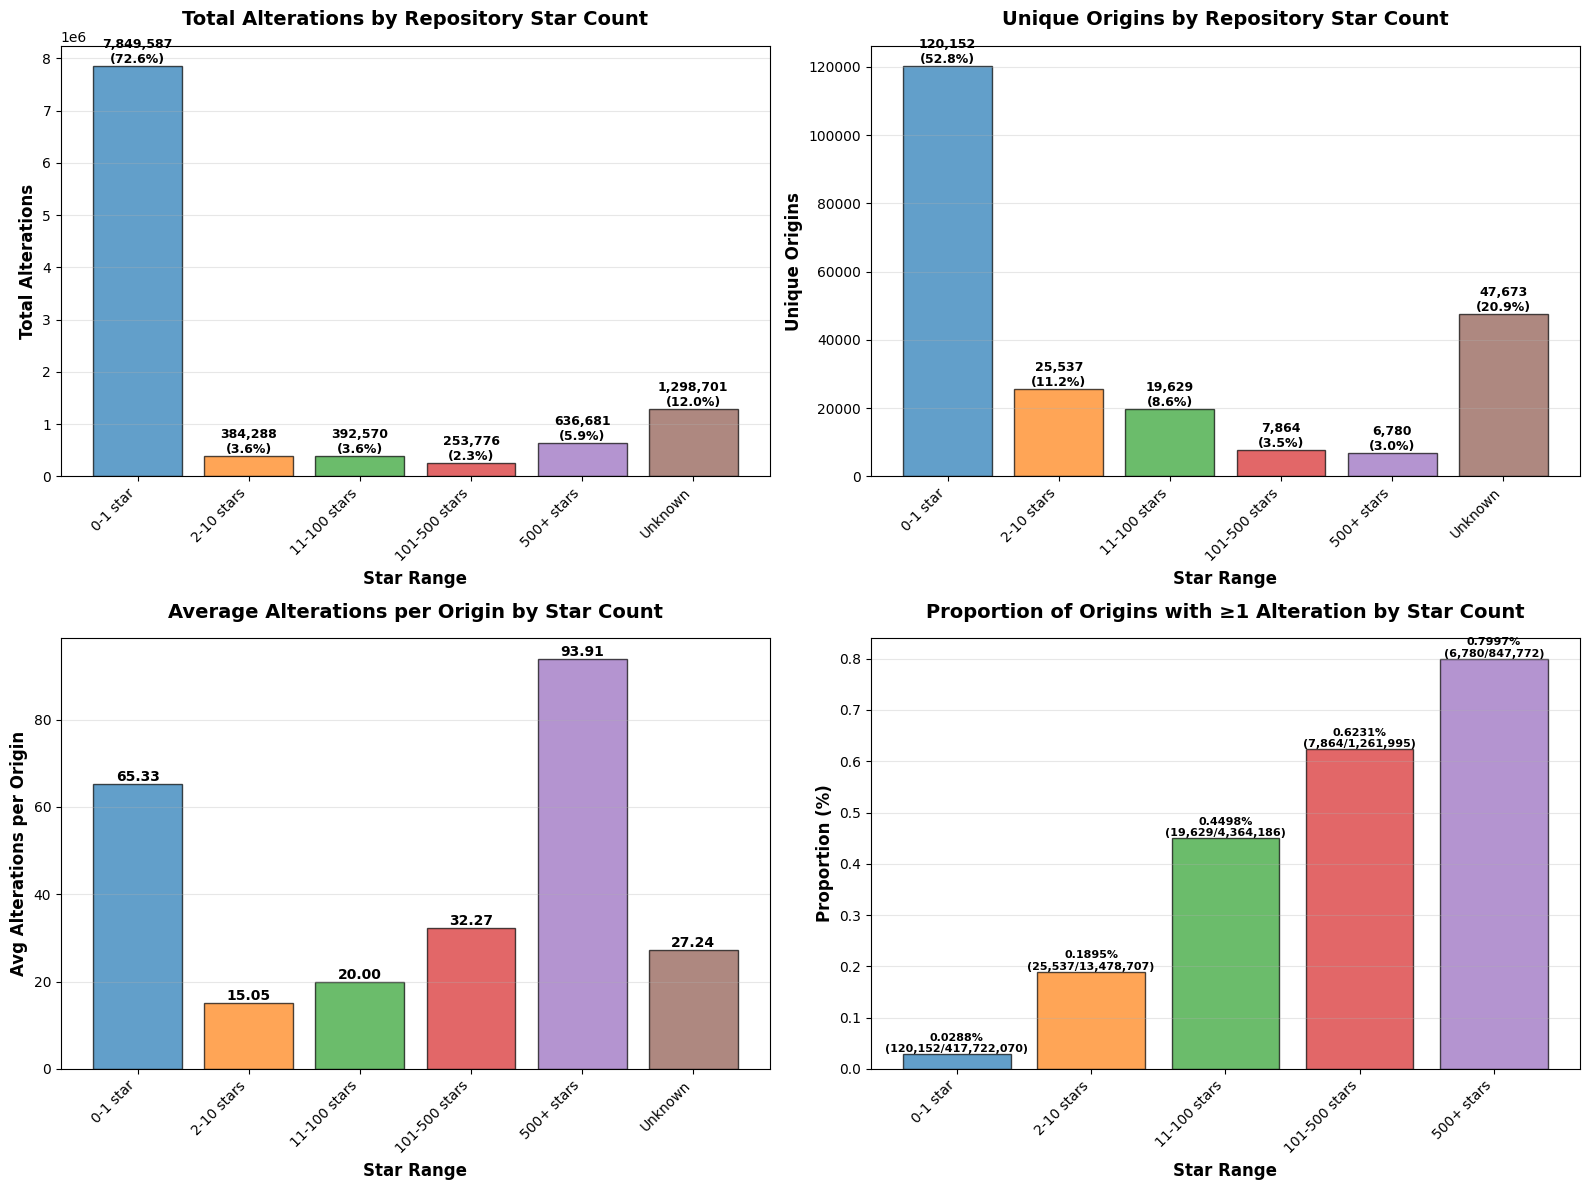


Visualization complete!
Key insights:
  - Most alterations come from: 0-1 star
  - Most origins in range: 0-1 star
  - Highest avg alterations per origin: 500+ stars (93.91)
  - Highest proportion with alterations: 500+ stars (0.7997%)


In [38]:
# Visualize star count statistics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define star order for plotting (exclude Unknown for some plots)
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
x_pos = range(len(star_stats))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# ============================================================
# PLOT 1: Total Alterations by Star Range (Bar Chart)
# ============================================================
ax1 = axes[0, 0]
bars1 = ax1.bar(x_pos, star_stats['total_alterations'], color=colors[:len(star_stats)], alpha=0.7, edgecolor='black')
ax1.set_xlabel('Star Range', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Alterations', fontsize=12, fontweight='bold')
ax1.set_title('Total Alterations by Repository Star Count', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['total_alterations']
    ax1.text(i, height, f"{height:,}\n({row['pct_alterations']:.1f}%)", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================
# PLOT 2: Unique Origins by Star Range (Bar Chart)
# ============================================================
ax2 = axes[0, 1]
bars2 = ax2.bar(x_pos, star_stats['unique_origins'], color=colors[:len(star_stats)], alpha=0.7, edgecolor='black')
ax2.set_xlabel('Star Range', fontsize=12, fontweight='bold')
ax2.set_ylabel('Unique Origins', fontsize=12, fontweight='bold')
ax2.set_title('Unique Origins by Repository Star Count', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['unique_origins']
    ax2.text(i, height, f"{height:,}\n({row['pct_origins']:.1f}%)", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================
# PLOT 3: Average Alterations per Origin (Bar Chart)
# ============================================================
ax3 = axes[1, 0]
star_stats['avg_per_origin'] = star_stats['total_alterations'] / star_stats['unique_origins']
bars3 = ax3.bar(x_pos, star_stats['avg_per_origin'], color=colors[:len(star_stats)], alpha=0.7, edgecolor='black')
ax3.set_xlabel('Star Range', fontsize=12, fontweight='bold')
ax3.set_ylabel('Avg Alterations per Origin', fontsize=12, fontweight='bold')
ax3.set_title('Average Alterations per Origin by Star Count', fontsize=14, fontweight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['avg_per_origin']
    ax3.text(i, height, f"{height:.2f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# ============================================================
# PLOT 4: Proportion of Origins with Alterations
# ============================================================
ax4 = axes[1, 1]
x_pos_prop = range(len(proportion_analysis))
bars4 = ax4.bar(x_pos_prop, proportion_analysis['proportion_with_alterations'], color=colors[:len(proportion_analysis)], alpha=0.7, edgecolor='black')
ax4.set_xlabel('Star Range', fontsize=12, fontweight='bold')
ax4.set_ylabel('Proportion (%)', fontsize=12, fontweight='bold')
ax4.set_title('Proportion of Origins with ≥1 Alteration by Star Count', fontsize=14, fontweight='bold', pad=15)
ax4.set_xticks(x_pos_prop)
ax4.set_xticklabels(proportion_analysis['star_range'], rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(proportion_analysis.iterrows()):
    height = row['proportion_with_alterations']
    ax4.text(i, height, f"{height:.4f}%\n({row['origins_with_alterations']:,}/{row['total_origins']:,})", 
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nVisualization complete!")
print(f"Key insights:")
print(f"  - Most alterations come from: {star_stats.loc[star_stats['total_alterations'].idxmax(), 'star_range']}")
print(f"  - Most origins in range: {star_stats.loc[star_stats['unique_origins'].idxmax(), 'star_range']}")
print(f"  - Highest avg alterations per origin: {star_stats.loc[star_stats['avg_per_origin'].idxmax(), 'star_range']} ({star_stats['avg_per_origin'].max():.2f})")
print(f"  - Highest proportion with alterations: {proportion_analysis.loc[proportion_analysis['proportion_with_alterations'].idxmax(), 'star_range']} ({proportion_analysis['proportion_with_alterations'].max():.4f}%)")

# Nix

In [6]:
nix_step3 = pd.read_csv("../correlation-results/step3_with_nixpkg_dates.csv")

In [ ]:
nix_step3

,attr_path,pname,version,forge_type,origin_url,owner,repo,rev,rev_type,hash,fetch_url,altered_tag,sha_before_alteration,old_snap_timestamp,sha_after_alteration,alteration_detected_at,first_commit_date,last_commit_date,primary_path,nixpkg_before_alteration,nixpkg_before_old_snap,days_from_first_commit_to_alteration
0,armips,armips,0.11.0,fetchFromGitHub,https://github.com/Kingcom/armips,Kingcom,armips,refs/tags/v0.11.0,tag,sha256-L+Uxww/WtvDJn1xZqoqA6Pkzq/98sy1qTxZbv6eEjbA=,https://github.com/Kingcom/armips/archive/refs/tags/v0.11.0.tar.gz,refs/tags/v0.11.0,swh:1:snp:18e62bde6a1e1933cca215d0cc2a5c9ded4cca88,2020-10-04 16:26:35+00:00,swh:1:snp:b02e6473e038a508e874bb6e990bbb8ee7f802ef,2022-01-25 17:44:03+00:00,2025-05-31 16:43:18+00:00,2025-12-10 17:56:58+00:00,pkgs/by-name/ar/armips/package.nix,False,False,-1221.957813
1,cozy,cozy,1.3.0,fetchFromGitHub,https://github.com/geigi/cozy,geigi,cozy,refs/tags/1.3.0,tag,sha256-oMgdz2dny0u1XV13aHu5s8/pcAz8z/SAOf4hbCDsdjw,https://github.com/geigi/cozy/archive/refs/tags/1.3.0.tar.gz,refs/tags/1.3.0,swh:1:snp:bfeb954cf866b15c9b5118bf333789f952a5d2c9,2023-12-04 13:28:03+00:00,swh:1:snp:56415de1de815c995b40b61e9218e434be5791ff,2024-02-17 06:52:31+00:00,2024-11-09 12:04:51+00:00,2025-12-10 17:56:58+00:00,pkgs/by-name/co/cozy/package.nix,False,False,-266.216898
2,cozy,cozy,1.3.0,fetchFromGitHub,https://github.com/geigi/cozy,geigi,cozy,refs/tags/1.3.0,tag,sha256-oMgdz2dny0u1XV13aHu5s8/pcAz8z/SAOf4hbCDsdjw,https://github.com/geigi/cozy/archive/refs/tags/1.3.0.tar.gz,refs/tags/1.3.0,swh:1:snp:56415de1de815c995b40b61e9218e434be5791ff,2024-02-17 06:52:31+00:00,swh:1:snp:f4e81bc603947f1644e193f8edc92c3707659ab0,2024-03-18 00:12:54+00:00,2024-11-09 12:04:51+00:00,2025-12-10 17:56:58+00:00,pkgs/by-name/co/cozy/package.nix,False,False,-236.494410
3,dosbox-staging,dosbox-staging,0.82.2,fetchFromGitHub,https://github.com/dosbox-staging/dosbox-staging,dosbox-staging,dosbox-staging,refs/tags/v0.82.2,tag,sha256-u9W6TfHF+BNeoExcx98kCVJu1BNwWnvjBEg84evMnBw=,https://github.com/dosbox-staging/dosbox-staging/archive/refs/tags/v0.82.2.tar.gz,refs/tags/v0.82.2,swh:1:snp:c80dfec390768deb3eb595840cc3d47b1172da55,2025-04-28 22:07:37+00:00,swh:1:snp:d0b42e4f57b69fd3b994a95a61a330e308d3e073,2025-06-20 15:50:10+00:00,2023-10-11 17:11:38+00:00,2025-07-22 13:19:36+00:00,pkgs/by-name/do/dosbox-staging/package.nix,True,True,617.943426
4,driftnet,driftnet,1.6.0,fetchFromGitHub,https://github.com/deiv/driftnet,deiv,driftnet,refs/tags/v1.6.0,tag,sha256-f7EPC/n3CyxVOXC6j43Nnwkgu/aDVst8lQpzfgegDsI=,https://github.com/deiv/driftnet/archive/refs/tags/v1.6.0.tar.gz,refs/tags/v1.6.0,swh:1:snp:0be0677e1b56037eaa6bf434b08d71d66c1acb7f,2025-04-30 07:13:44+00:00,swh:1:snp:8119fb6781ce62841ae1192723e5bfda0dea7ced,2025-05-13 02:33:41+00:00,2024-11-09 12:04:51+00:00,2025-12-07 19:52:19+00:00,pkgs/by-name/dr/driftnet/package.nix,True,True,184.603356
5,faraday-agent-dispatcher,faraday-agent-dispatcher,3.4.2,fetchFromGitHub,https://github.com/infobyte/faraday_agent_dispatcher,infobyte,faraday_agent_dispatcher,refs/tags/3.4.2,tag,sha256-Qr3ZGU4y7f6yHD78ecdv7a6IBFDpT+/4Yez0n/MenN0=,https://github.com/infobyte/faraday_agent_dispatcher/archive/refs/tags/3.4.2.tar.gz,refs/tags/3.4.2,swh:1:snp:1bc292c9f88b116ba209a32d3ceb75ba52b036f9,2024-07-10 23:57:01+00:00,swh:1:snp:c44391387690b21ef3df446d52f2af77cab4df15,2024-07-22 01:55:47+00:00,2024-11-09 12:04:51+00:00,2025-06-02 06:42:56+00:00,pkgs/by-name/fa/faraday-agent-dispatcher/package.nix,False,False,-110.422963
6,gamemode,gamemode,1.8.2,fetchFromGitHub,https://github.com/FeralInteractive/gamemode,FeralInteractive,gamemode,refs/tags/1.8.2,tag,sha256-V0rewbSVOGFqJqXyCz4jXpuDM0EfjdkpGPl+WdDwI5I=,https://github.com/FeralInteractive/gamemode/archive/refs/tags/1.8.2.tar.gz,refs/tags/1.8.2,swh:1:snp:ce0233d3eb10836f2f1cbb6837e37d6294a6a0a5,2024-08-30 21:47:20+00:00,swh:1:snp:4030d251cc4786035ba073a598ce7192469a34d4,2024-09-14 21:49:26+00:00,2021-05-18 00:31:45+00:00,2025-01-27 01:10:23+00:00,nixos/modules/